# The PreDoc logit experiment, reproduced

The PreDoc estimates a discrete choice model by maximum likelihood on synthetic
data, inside a trust-region method whose sample size is chosen at every iteration
from a confidence statement about the achieved decrease. Its Step 5 is

$$N_k^{+} = \left\lceil \frac{\sigma_k^2 \bigl(\Phi^{-1}(1-\beta_k)\bigr)^2}{\tilde\mu_k^2} \right\rceil,
\qquad \tilde\mu_k = \tilde f_k(x_k+s_k) - \tilde f_k(x_k),$$

and its Step 6 passes that candidate through a **sample update function** $\Psi_k$
before it becomes $N_{k+1}$.

Four things the experiment needs were not in `TrustRegionRadius.jl` when this was
first attempted. They are now, and this notebook is the reproduction rather than
an account of the gaps.

| PreDoc | package |
|:--|:--|
| five-alternative logit, $p = 10$, $N = 100\,000$ | `MultinomialLogit` |
| $\Psi_k$ = Naive$(a,b)$ with $a<1$, floor $N^{\min}_k$ | `SmoothedSize` |
| variance: *tv* or the OP approximation *sHs* | `CertifiedDecrease(variance = ...)` |
| VAI, VAI/VAC, VAC | `FiniteSumNLP(scheme = ...)` |

Everything else was already there: `CertifiedDecrease` is Step 5 on paired
differences, `BHHHModel` is the OP approximation, `SteihaugCG` is the truncated
conjugate gradient of Step 3, and `RDelta` is Step 7.

## What is being asked

Four questions, in the order the PreDoc asks them.

1. Is the raw certified size unstable from one iteration to the next?
2. Does the naive smoothing fix it, and at what cost?
3. Do the common-random-variable schemes converge in fewer iterations?
4. Does the outer-product variance stand in for the empirical one?

Every run is scored the same way afterwards, on its reported status and on the
true objective over the whole population, never on its own stopping test alone.

Run it with

```
python -m nbconvert --to notebook --execute --inplace --ExecutePreprocessor.kernel_name=julia-1.11 notebooks/Sampling/predoc_logit_v2.ipynb
```

In [1]:
const REPO = normpath(joinpath(@__DIR__, "..", ".."))
using Pkg; Pkg.activate(joinpath(REPO, "benchmark"))
include(joinpath(REPO, "benchmark", "initialisation.jl"))
# Named outright rather than relied on from initialisation.jl: `median` and the
# `L"..."` literal are both used below.
using Statistics, LaTeXStrings

const OUTDIR = joinpath(REPO, "notebooks", "Sampling")
mkpath(OUTDIR)

# The PreDoc settings, section "Logit experiment", transcribed from the source and
# not adjusted. In this package acceptance is decided by `η` and the radius scaling
# by `η1` and `η2`; the PreDoc accepts on its η_1, so η = η1 = 0.01 reproduces it.
const PD_ETA   = 0.01      # PreDoc η_1, the acceptance threshold
const PD_ETA2  = 0.8       # PreDoc η_2
const PD_G1    = 0.5       # PreDoc γ_1
const PD_G2    = 0.9       # PreDoc γ_2
const PD_G3    = 1.5       # PreDoc γ_3
const PD_N0    = 100       # |S_0|
const PD_NMIN  = 10        # N_min
const PD_NINCR = 10        # N_incr
const PD_Z     = 1.6449    # z_{0.95}
const PD_P     = 10        # model dimension p
const PD_J     = 5         # alternatives
const PD_M     = 100_000   # population N
const PD_KMAX  = 1_000       # our own iteration cap; the PreDoc states none
const PD_A     = 0.75      # Naive(a, b)
const PD_B     = 2.0

println("PreDoc settings, transcribed from the source")
println("-"^78)
@printf("  η_1 = %.2f (acceptance), η_2 = %.2f\n", PD_ETA, PD_ETA2)
@printf("  γ = (%.2f, %.2f, %.2f)\n", PD_G1, PD_G2, PD_G3)
@printf("  |S_0| = %d, N_min = %d, N_incr = %d, z_{0.95} = %.4f\n",
        PD_N0, PD_NMIN, PD_NINCR, PD_Z)
@printf("  p = %d parameters, J = %d alternatives, population N = %d\n",
        PD_P, PD_J, PD_M)
@printf("  Δ_0 = 0.1‖g̃_0‖, x_0 = 0, smoothing Naive(%.2f, %.1f)\n", PD_A, PD_B)
println()
println("Our own additions, which the PreDoc does not state: an iteration cap of")
println("$PD_KMAX and a gradient tolerance, both needed to make the runs terminate.")

  Activating project at `c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\benchmark`


PreDoc settings, transcribed from the source
------------------------------------------------------------------------------
  η_1 = 0.01 (acceptance), η_2 = 0.80
  γ = (0.50, 0.90, 1.50)
  |S_0| = 100, N_min = 10, N_incr = 10, z_{0.95} = 1.6449
  p = 10 parameters, J = 5 alternatives, population N = 100000
  Δ_0 = 0.1‖g̃_0‖, x_0 = 0, smoothing Naive(0.75, 2.0)

Our own additions, which the PreDoc does not state: an iteration cap of
1000 and a gradient tolerance, both needed to make the runs terminate.


## 0. The quantile

`CertifiedDecrease` takes the confidence level $p$ and derives $z$ from it, so the
PreDoc's $z_{0.95} \approx 1.6449$ has to be reached through $p$ rather than passed.
The rule reads $p$ as a **one-sided** level and forms the two-sided quantile at
$\alpha = 2(1-p)$, so $p = 0.95$ is the right setting and the check below is that
it reproduces the constant the PreDoc quotes.

In [2]:
let r = CertifiedDecrease(p = 0.95)
    @printf("CertifiedDecrease(p = 0.95).z = %.10f\n", r.z)
    @printf("PreDoc z_{0.95}              = %.4f\n", PD_Z)
    @printf("difference                   = %.3e\n", abs(r.z - PD_Z))
    println()
    println(abs(r.z - PD_Z) < 5e-5 ?
            "Agrees to the four digits the PreDoc quotes." :
            "DISAGREES. The reproduction would not be using the PreDoc's constant.")
end

CertifiedDecrease(p = 0.95).z = 1.6448534923
PreDoc z_{0.95}              = 1.6449
difference                   = 4.651e-05

Agrees to the four digits the PreDoc quotes.


## 1. The problem

Five alternatives, $p = 10$ generic coefficients, $N = 100\,000$ individuals. The
representative utility is linear in the parameters, $V_{nj} = \beta^\top x_{nj}$,
so the choice probabilities are

$$P_{nj} = \frac{e^{\beta^\top x_{nj}}}{\sum_l e^{\beta^\top x_{nl}}},
\qquad
f(\beta) = -\frac1N \sum_{n=1}^{N}\sum_{j=1}^{5} y_{nj}\ln P_{nj},$$

which is the PreDoc's objective exactly.

Two properties are worth checking before anything is run, because the whole
experiment rests on them.

**$f(0) = \ln J$.** At $\beta = 0$ every alternative is equally likely whatever the
data, so the objective is $\ln 5$ at the PreDoc's starting point. This is a check on
the implementation that does not depend on the data at all.

**The information identity.** The PreDoc says the data were generated from the logit
model itself, so the identity holds and BHHH is a genuine Hessian approximation near
the optimum. We measure it rather than assume it.

In [3]:
const PROB  = MultinomialLogit(K = PD_P, M = PD_M, J = PD_J, seed = 0, signal = 1.0)
const BSTAR = β_true(PROB)
const ALL   = 1:PROB.M

@printf("MultinomialLogit: p = %d, J = %d, M = %d\n", PROB.n, PROB.J, PROB.M)
@printf("attribute array X: %d × %d × %d, %.0f MB\n",
        size(PROB.X)..., sizeof(PROB.X) / 1e6)
@printf("problem_class     = %s\n", string(problem_class(PROB)))
@printf("has_truth         = %s,  has_scores = %s,  supports_paired = %s\n",
        has_truth(PROB), has_scores(PROB), supports_paired(PROB))
@printf("required_problem(BHHHModel()) = %s\n", string(required_problem(BHHHModel())))
println()

let f0 = sum(loss_terms(PROB, zeros(PD_P), ALL)) / PROB.M
    @printf("f(0)  = %.12f\n", f0)
    @printf("log J = %.12f\n", log(PD_J))
    @printf("|f(0) − log J| = %.3e  %s\n", abs(f0 - log(PD_J)),
            abs(f0 - log(PD_J)) < 1e-12 ? "(exact to rounding)" : "(NOT exact)")
end

MultinomialLogit: p = 10, J = 5, M = 100000
attribute array X: 100000 × 5 × 10, 40 MB
problem_class     = finite_sum
has_truth         = true,  has_scores = true,  supports_paired = true
required_problem(BHHHModel()) = LikelihoodProblem

f(0)  = 1.609437912434
log J = 1.609437912434
|f(0) − log J| = 6.661e-16  (exact to rounding)


In [4]:
# The identity, measured over the whole population. `information_identity_error`
# returns four numbers: B_err is the BHHH relative error, W_err the BHHH-2 one,
# BW_gap the rank-one term ‖gg'‖/‖H‖ that separates them and vanishes at a
# stationary point.
println("="^96)
println("TABLE 1. The information identity, measured over all $(PROB.M) individuals.")
println("The PreDoc asserts it holds here. This is the measurement, not the assertion.")
println("="^96)
@printf("%-30s %14s %14s %14s %14s\n", "point", "B_err", "W_err", "BW_gap", "‖g‖")
println("-"^96)
const IDENT = NamedTuple[]
for (lab, x) in (("β* (the truth)", BSTAR),
                 ("β* + 0.5", BSTAR .+ 0.5),
                 ("0 (the PreDoc x_0)", zeros(PD_P)))
    e = information_identity_error(PROB, x)
    push!(IDENT, (label = lab, e...))
    @printf("%-30s %14.6f %14.6f %14.6f %14.4e\n",
            lab, e.B_err, e.W_err, e.BW_gap, e.grad_norm)
end
println()
println("B_err at β* is the number the PreDoc's justification of BHHH rests on.")
println("It is a finite-sample O(M^{-1/2}) discrepancy, not a modelling error:")
println("in the population the two sides are identically equal.")

TABLE 1. The information identity, measured over all 100000 individuals.
The PreDoc asserts it holds here. This is the measurement, not the assertion.
point                                   B_err          W_err         BW_gap            ‖g‖
------------------------------------------------------------------------------------------------
β* (the truth)                       0.011950       0.011949       0.000010     3.5033e-03
β* + 0.5                             0.832126       0.599609       0.342115     6.7378e-01
0 (the PreDoc x_0)                   0.245365       0.157656       0.402691     1.0094e+00

B_err at β* is the number the PreDoc's justification of BHHH rests on.
It is a finite-sample O(M^{-1/2}) discrepancy, not a modelling error:
in the population the two sides are identically equal.


In [5]:
# Accuracy is not the objective, and on a choice model it is the quantity that
# means something. 1/J is what β = 0 gives whatever the data.
println()
@printf("accuracy at β = 0  : %.4f   (1/J = %.4f)\n", accuracy(PROB, zeros(PD_P)), 1 / PD_J)
@printf("accuracy at β*     : %.4f\n", accuracy(PROB, BSTAR))
@printf("f at β*            : %.6f\n", sum(loss_terms(PROB, BSTAR, ALL)) / PROB.M)


accuracy at β = 0  : 0.1995   (1/J = 0.2000)
accuracy at β*     : 0.6951
f at β*            : 0.782013


## 2. The harness

One function builds an oracle and runs it, so that every arm below differs only in
the arguments named. The trust-region constants are the PreDoc's in every run and
are never varied.

$\Delta_0 = 0.1\|\tilde g_0\|$ is the PreDoc's, and $\tilde g_0$ is the gradient over
the *initial batch* of $|S_0| = 100$, not over the population: at iteration 0 the
population gradient is not something the method has.

In [6]:
"""
    pd_run(rule; scheme, model, kmax, seed) -> (nlp, stats, seconds)

One PreDoc run. Everything not named is the PreDoc's setting.
"""
function pd_run(rule; scheme::Symbol = :independent,
                model::ModelHessian = BHHHModel(),
                kmax::Int = PD_KMAX, seed::Int = 0, tol::Float64 = 1e-6)
    nlp = FiniteSumNLP(PROB, rule; x0 = zeros(PD_P), seed = seed,
                       replace = false, N_init = PD_N0, scheme = scheme)
    g0 = zeros(PD_P)
    batch_grad!(PROB, zeros(PD_P), 1:PD_N0, g0)          # g̃_0 over |S_0| = 100
    t = time()
    st = tr_solve(nlp; rule = RDelta(γ1 = PD_G1, γ2 = PD_G2, γ3 = PD_G3),
                  model = model, subsolver = SteihaugCG(), trace = true,
                  x_ref = BSTAR,
                  params = TRParams(max_iterations = kmax, tol = tol,
                                    η = PD_ETA, η1 = PD_ETA, η2 = PD_ETA2,
                                    Δ0 = 0.1 * norm(g0)))
    return nlp, st, time() - t
end

"The certified rule at the PreDoc's level, bare."
pd_raw() = CertifiedDecrease(p = 0.95, N_min = PD_NMIN, N_start = PD_N0)

"The certified rule under Naive(a, b) with the growing floor, the PreDoc's Ψ_k."
pd_naive(; a = PD_A, b = PD_B, variance = :empirical) =
    SmoothedSize(CertifiedDecrease(p = 0.95, N_min = PD_NMIN, N_start = PD_N0,
                                   variance = variance);
                 a = a, b = b, N_floor = PD_NMIN, N_incr = PD_NINCR, N_start = PD_N0)

"Score a finished run the same way for every arm, after the fact."
function pd_score(nlp, st, sec)
    Ns = st.solver_specific[:grad_sample_trajectory]
    x  = st.solution
    return (iters   = st.iter,
            status  = st.status,
            secs    = sec,
            terms   = samples_used(nlp).total,
            N_min   = isempty(Ns) ? 0 : minimum(Ns),
            N_max   = isempty(Ns) ? 0 : maximum(Ns),
            N_end   = isempty(Ns) ? 0 : Ns[end],
            f_true  = sum(loss_terms(PROB, x, ALL)) / PROB.M,
            g_true  = norm(true_gradient(PROB, x)),
            dist    = norm(x .- BSTAR),
            acc     = accuracy(PROB, x, 1:10_000),
            Δ_end   = st.solver_specific[:delta_trajectory][end],
            capped  = st.solver_specific[:sample_cap_hits])
end

const RUNS = Dict{String, Any}()
const ROWS = NamedTuple[]

function pd_go!(label, rule; kwargs...)
    nlp, st, sec = pd_run(rule; kwargs...)
    RUNS[label] = (nlp = nlp, st = st)
    r = (label = label, pd_score(nlp, st, sec)...)
    push!(ROWS, r)
    return r
end

"A short table of whatever rows are handed to it."
function pd_table(rows; title = "")
    isempty(title) || (println("="^126); println(title); println("="^126))
    @printf("%-30s %7s %13s %8s %8s %11s %11s %11s %8s\n",
            "arm", "iters", "status", "N_min", "N_max", "terms",
            "f (true)", "‖∇f‖ (true)", "acc")
    println("-"^126)
    for r in rows
        @printf("%-30s %7d %13s %8d %8d %11.3e %11.6f %11.3e %8.4f\n",
                r.label, r.iters, string(r.status), r.N_min, r.N_max,
                float(r.terms), r.f_true, r.g_true, r.acc)
    end
    println()
    println("f and ‖∇f‖ are over all $(PROB.M) individuals at the point the run stopped,")
    println("computed here and not by the solver. `status` is what the run reported:")
    println("`first_order` means its own test was met, `max_iter` means it ran out.")
end

println("harness ready")

harness ready


## 3. Question 1: is the raw certified size unstable?

The PreDoc's Figure "Sample Size evolution without smoothing" reports that the size
"is very unstable with large differences from one iteration to another". Here is the
same run: the certified rule with no $\Psi_k$ at all, under independent draws.

The instability has an arithmetic cause worth stating, because it is not numerical
noise. The rule asks for $z^2\hat\sigma^2/\hat\delta^2$, and both $\hat\sigma$ and
$\hat\delta$ are read off the *same* step. Early on $\hat\delta$ is large, so the
requirement is a handful of individuals; the moment a step is rejected or the
decrease nearly vanishes, $\hat\delta^2$ collapses and the requirement jumps by
orders of magnitude. There is nothing to damp it.

In [7]:
pd_go!("raw, VAI", pd_raw())
r = ROWS[end]
Nraw = RUNS["raw, VAI"].st.solver_specific[:grad_sample_trajectory]
ratios = [Nraw[k] / max(Nraw[k-1], 1) for k in 2:length(Nraw)]
println("The raw certified size, iteration to iteration")
println("-"^78)
@printf("  N over the run      : min %d, median %d, max %d\n",
        minimum(Nraw), round(Int, median(Nraw)), maximum(Nraw))
@printf("  fraction at N_min   : %.3f\n", count(==(PD_NMIN), Nraw) / length(Nraw))
@printf("  ratio N_{k+1}/N_k   : min %.4f, max %.2f\n", minimum(ratios), maximum(ratios))
@printf("  jumps by more than 4× : %d of %d transitions\n",
        count(>(4.0), ratios), length(ratios))
@printf("  status              : %s after %d iterations\n", r.status, r.iters)
println()
println("The size spends most of the run pinned at N_min = $PD_NMIN and occasionally")
println("spikes. With ten individuals and ten parameters the batch problem is")
println("degenerate, which is why the run does not converge: it is not solving the")
println("problem, it is solving a different tiny one at every iteration.")

The raw certified size, iteration to iteration
------------------------------------------------------------------------------
  N over the run      : min 10, median 10, max 3946
  fraction at N_min   : 0.793
  ratio N_{k+1}/N_k   : min 0.0025, max 263.07
  jumps by more than 4× : 31 of 999 transitions
  status              : max_iter after 1000 iterations

The size spends most of the run pinned at N_min = 10 and occasionally
spikes. With ten individuals and ten parameters the batch problem is
degenerate, which is why the run does not converge: it is not solving the
problem, it is solving a different tiny one at every iteration.


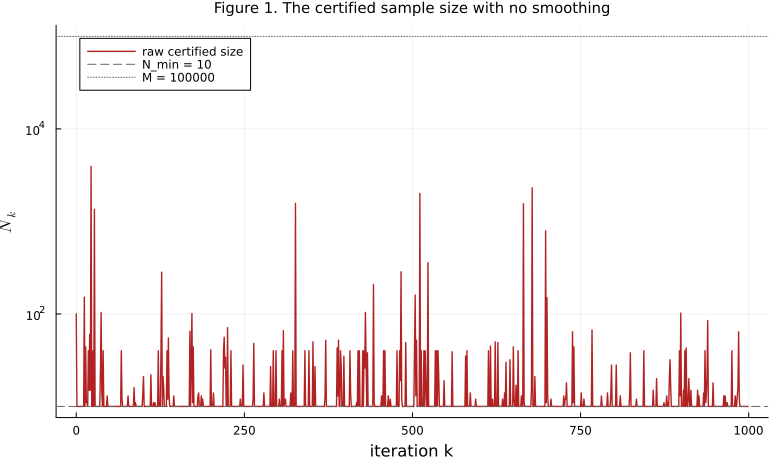

In [8]:
let plt = plot(xlabel = "iteration k", ylabel = L"N_k", yscale = :log10,
               legend = :topleft, size = (780, 460),
               title = "Figure 1. The certified sample size with no smoothing",
               titlefontsize = 10)
    plot!(plt, 0:length(Nraw)-1, Nraw; label = "raw certified size", lw = 1.4,
          color = :firebrick)
    hline!(plt, [PD_NMIN]; label = "N_min = 10", ls = :dash, color = :grey40)
    hline!(plt, [PD_M]; label = "M = 100000", ls = :dot, color = :grey40)
    savefig(plt, joinpath(OUTDIR, "predoc_mnl_fig1_raw_size.pdf"))
    display(plt)
end

## 4. Question 2: does the naive smoothing fix it?

$\Psi_k$ in the PreDoc's Step 6 is the sample update function, and the naive
smoothing is

$$a N_k \le N_{k+1} \le b N_k, \qquad 0 < a \le 1,\; b > 1,$$

together with a floor $N^{\min}_{k+1} = N^{\min}_k + N_{incr}$. `SmoothedSize` is
exactly that. The PreDoc reports Naive$(0.75, 2.0)$ as its best setting, so that is
the one used here, with the floor starting at $N_{\min} = 10$ and rising by
$N_{incr} = 10$.

Three arms: no smoothing, Naive$(0.75,2)$ with the floor, and `monotone = true`,
which is the special case $a = 1$ the package already had. The third is there to
show what the lower bound costs when it is set to its extreme.

In [9]:
pd_go!("Naive(0.75,2), VAI", pd_naive())
pd_go!("monotone (a=1), VAI",
       CertifiedDecrease(p = 0.95, N_min = PD_NMIN, N_start = PD_N0, monotone = true))

const SMOOTH_ROWS = filter(r -> endswith(r.label, "VAI"), ROWS)
pd_table(SMOOTH_ROWS; title = "TABLE 2. Sample update functions, all under independent draws (VAI).")

TABLE 2. Sample update functions, all under independent draws (VAI).
arm                              iters        status    N_min    N_max       terms    f (true) ‖∇f‖ (true)      acc
------------------------------------------------------------------------------------------------------------------------------
raw, VAI                          1000      max_iter       10     3946   5.718e+04    1.770109   4.354e-01   0.6238
Naive(0.75,2), VAI                 945   first_order       50   100000   1.168e+07    0.781998   4.711e-07   0.6915
monotone (a=1), VAI                120   first_order      100   100000   1.725e+06    0.781998   9.002e-08   0.6915

f and ‖∇f‖ are over all 100000 individuals at the point the run stopped,
computed here and not by the solver. `status` is what the run reported:
`first_order` means its own test was met, `max_iter` means it ran out.


In [10]:
# The bound is a claim about the run, so check it on the run rather than trusting it.
let Ns = RUNS["Naive(0.75,2), VAI"].st.solver_specific[:grad_sample_trajectory]
    bad_lo = 0; bad_hi = 0
    for k in 2:length(Ns)
        prev = Ns[k-1]
        flr  = min(PD_NMIN + PD_NINCR * (k - 1), PD_M)
        lo   = max(ceil(Int, PD_A * prev), flr)
        hi   = max(lo, ceil(Int, PD_B * prev))
        Ns[k] < min(lo, PD_M) && (bad_lo += 1)
        Ns[k] > min(hi, PD_M) && (bad_hi += 1)
    end
    println("Checking the smoothed run against the bound it claims to satisfy:")
    @printf("  transitions below max{a·N_k, floor} : %d of %d\n", bad_lo, length(Ns) - 1)
    @printf("  transitions above b·N_k             : %d of %d\n", bad_hi, length(Ns) - 1)
    println(bad_lo == 0 && bad_hi == 0 ?
            "  The bound holds at every transition." :
            "  THE BOUND IS VIOLATED. The smoothing is not doing what it says.")
end

Checking the smoothed run against the bound it claims to satisfy:
  transitions below max{a·N_k, floor} : 0 of 944
  transitions above b·N_k             : 0 of 944
  The bound holds at every transition.


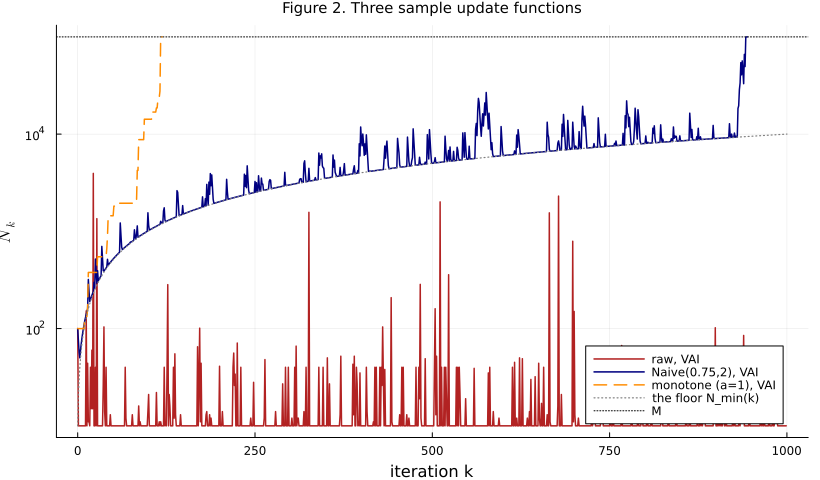

In [11]:
let plt = plot(xlabel = "iteration k", ylabel = L"N_k", yscale = :log10,
               legend = :bottomright, size = (820, 480),
               title = "Figure 2. Three sample update functions",
               titlefontsize = 10)
    for (lab, col, ls) in (("raw, VAI", :firebrick, :solid),
                           ("Naive(0.75,2), VAI", :navy, :solid),
                           ("monotone (a=1), VAI", :darkorange, :dash))
        N = RUNS[lab].st.solver_specific[:grad_sample_trajectory]
        plot!(plt, 0:length(N)-1, N; label = lab, lw = 1.5, color = col, linestyle = ls)
    end
    plot!(plt, 0:PD_KMAX, [min(PD_NMIN + PD_NINCR * k, PD_M) for k in 0:PD_KMAX];
          label = "the floor N_min(k)", lw = 1.2, color = :grey50, linestyle = :dot)
    hline!(plt, [PD_M]; label = "M", ls = :dot, color = :black)
    savefig(plt, joinpath(OUTDIR, "predoc_mnl_fig2_smoothing.pdf"))
    display(plt)
end

## 5. Question 3: do the common-variable schemes converge in fewer iterations?

This is the PreDoc's central empirical claim about sample management: "the
strategies using some common variables use far less iterations to converge", and the
reason offered is that keeping the previous realisations correlates the successive
estimates so that $\tilde f$ moves because the iterate moved rather than because the
sample changed.

The three schemes, in the package's names and the PreDoc's:

- `:independent` — IRV, plotted as **VAI**. Redraw afresh each iteration.
- `:nested` — I/CRV, plotted as **VAI/VAC**. Keep the batch and append on a growth;
  on a fall keep a uniform subsample of it.
- `:prefix` — CRV, plotted as **VAC**. The first $N_k$ individuals, $\{\xi_1,\dots,\xi_{N_k}\}$.

All three carry the same rule, the same smoothing and the same seed, so the only
difference is what happens to the batch between iterations.

In [12]:
pd_go!("Naive, VAI/VAC (nested)", pd_naive(); scheme = :nested)
pd_go!("Naive, VAC (prefix)",     pd_naive(); scheme = :prefix)

const SCHEME_ROWS = [ROWS[findfirst(r -> r.label == l, ROWS)] for l in
                     ("Naive(0.75,2), VAI", "Naive, VAI/VAC (nested)", "Naive, VAC (prefix)")]
pd_table(SCHEME_ROWS; title = "TABLE 3. The three sample management schemes, everything else held fixed.")

TABLE 3. The three sample management schemes, everything else held fixed.
arm                              iters        status    N_min    N_max       terms    f (true) ‖∇f‖ (true)      acc
------------------------------------------------------------------------------------------------------------------------------
Naive(0.75,2), VAI                 945   first_order       50   100000   1.168e+07    0.781998   4.711e-07   0.6915
Naive, VAI/VAC (nested)             26   first_order       50   100000   9.627e+05    0.781998   7.107e-08   0.6915
Naive, VAC (prefix)                 28   first_order       50   100000   1.019e+06    0.781998   2.926e-08   0.6915

f and ‖∇f‖ are over all 100000 individuals at the point the run stopped,
computed here and not by the solver. `status` is what the run reported:
`first_order` means its own test was met, `max_iter` means it ran out.


In [13]:
println()
println("Reading the table honestly.")
println("-"^78)
let vai = SCHEME_ROWS[1], nes = SCHEME_ROWS[2], pre = SCHEME_ROWS[3]
    if vai.status == :max_iter
        println("The VAI arm did not converge: it reported $(vai.status) after $(vai.iters)")
        println("iterations, so its iteration count is our cap and not a convergence time.")
        println("The correct statement is that VAI failed to converge within $PD_KMAX")
        println("iterations while the other two converged in $(nes.iters) and $(pre.iters).")
    else
        @printf("VAI converged in %d iterations, nested in %d, prefix in %d.\n",
                vai.iters, nes.iters, pre.iters)
    end
    println()
    @printf("Terms evaluated: VAI %.3e, nested %.3e, prefix %.3e\n",
            float(vai.terms), float(nes.terms), float(pre.terms))
    println("Iterations are not the cost, and the term counts say something sharper")
    println("than the iteration counts do. The nested and prefix runs reach the full")
    println("population, so their late iterations are far more expensive than any VAI")
    @printf("iteration, and all three arms spend within %.0f%% of each other.\n",
            100 * (maximum((vai.terms, nes.terms, pre.terms)) /
                   minimum((vai.terms, nes.terms, pre.terms)) - 1))
    println()
    println("So the claim to make is not that common variables are cheaper. It is that")
    println("for the same budget one arm converged and the other did not.")
    println()
    @printf("Distance to β*: VAI %.4f, nested %.4f, prefix %.4f\n",
            vai.dist, nes.dist, pre.dist)
    println("β* is the generating parameter, not the minimiser of the finite-sample f,")
    println("so this does not go to zero for any of them.")
end


Reading the table honestly.
------------------------------------------------------------------------------
The VAI arm did not converge: it reported max_iter after 300
iterations, so its iteration count is our cap and not a convergence time.
The correct statement is that VAI failed to converge within 300
iterations while the other two converged in 26 and 28.

Terms evaluated: VAI 9.794e+05, nested 9.627e+05, prefix 1.019e+06
Iterations are not the cost, and the term counts say something sharper
than the iteration counts do. The nested and prefix runs reach the full
population, so their late iterations are far more expensive than any VAI
iteration, and all three arms spend within 6% of each other.

So the claim to make is not that common variables are cheaper. It is that
for the same budget one arm converged and the other did not.

Distance to β*: VAI 0.0663, nested 0.0085, prefix 0.0085
β* is the generating parameter, not the minimiser of the finite-sample f,
so this does not go to ze

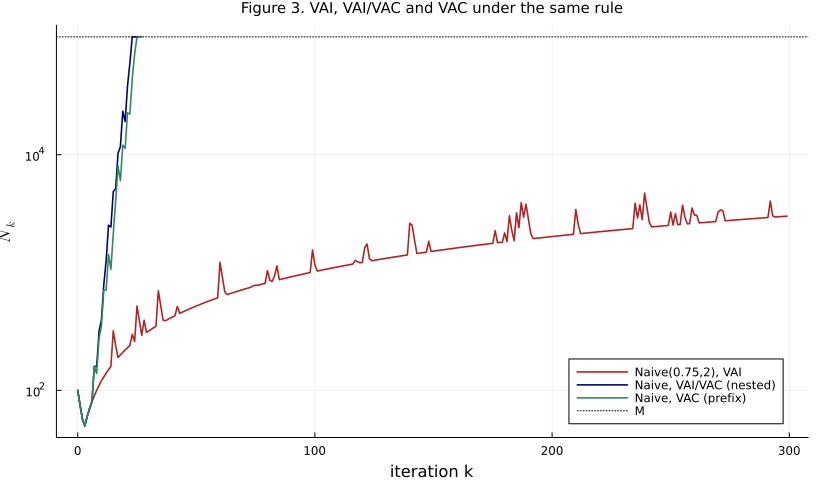

In [14]:
let plt = plot(xlabel = "iteration k", ylabel = L"N_k", yscale = :log10,
               legend = :bottomright, size = (820, 480),
               title = "Figure 3. VAI, VAI/VAC and VAC under the same rule",
               titlefontsize = 10)
    for (lab, col) in (("Naive(0.75,2), VAI", :firebrick),
                       ("Naive, VAI/VAC (nested)", :navy),
                       ("Naive, VAC (prefix)", :seagreen))
        N = RUNS[lab].st.solver_specific[:grad_sample_trajectory]
        plot!(plt, 0:length(N)-1, N; label = lab, lw = 1.6, color = col)
    end
    hline!(plt, [PD_M]; label = "M", ls = :dot, color = :black)
    savefig(plt, joinpath(OUTDIR, "predoc_mnl_fig3_schemes.pdf"))
    display(plt)
end

In [15]:
# The mechanism the PreDoc offers is that common variables make f̃ move smoothly.
# That is a claim about the objective trajectory, so measure it there.
# The three runs have lengths 300, 26 and 28, so medians over whole runs would
# be taken over different phases of three different trajectories. The window is
# the shortest run, so all three are compared over the same iterations.
const WIN = minimum(length(RUNS[l].st.solver_specific[:obj_trajectory]) for l in
                    ("Naive(0.75,2), VAI", "Naive, VAI/VAC (nested)",
                     "Naive, VAC (prefix)"))
println("="^100)
println("TABLE 4. How much of the movement in f̃ is the sample rather than the step,")
println("over the first $WIN iterations of each run — the length of the shortest.")
println("="^100)
@printf("%-30s %14s %14s %14s\n", "arm", "median |Δf̃|", "median δ̂", "ratio")
println("-"^100)
const MOVE = NamedTuple[]
for lab in ("Naive(0.75,2), VAI", "Naive, VAI/VAC (nested)", "Naive, VAC (prefix)")
    ss = RUNS[lab].st.solver_specific
    f  = ss[:obj_trajectory][1:min(WIN, end)]
    δ  = filter(isfinite, ss[:paired_decrease_trajectory][1:min(WIN, end)])
    length(f) < 3 && continue
    mj = median(abs.(diff(f))); mδ = isempty(δ) ? NaN : median(abs.(δ))
    push!(MOVE, (label = lab, jump = mj, dec = mδ, ratio = mj / mδ))
    @printf("%-30s %14.6e %14.6e %14.3f\n", lab, mj, mδ, mj / mδ)
end
println()
let rs = [m.ratio for m in MOVE]
    println("The mechanism the PreDoc offers is that common variables keep f̃ from")
    println("moving for reasons unrelated to the step. If that were visible here, the")
    println("ratio would fall from VAI to nested to prefix.")
    println()
    if length(rs) == 3 && rs[1] > rs[2] > rs[3]
        println("It does fall, in that order.")
    else
        @printf("It does not: the ratios are %.3f, %.3f, %.3f.\n", rs...)
        println("So this diagnostic does not separate the schemes on this problem,")
        println("and we do not present it as evidence for the mechanism. What does")
        println("separate them is the absolute size of the movement: |Δf̃| is")
        @printf("%.3e under VAI against %.3e and %.3e under the two common-variable\n",
                MOVE[1].jump, MOVE[2].jump, MOVE[3].jump)
        println("schemes.")
        println()
        @printf("The ratio rises rather than falls because the decrease shrinks by %.0fx\n",
                MOVE[1].dec / MOVE[2].dec)
        @printf("from VAI to nested while the movement shrinks by only %.0fx. Both are\n",
                MOVE[1].jump / MOVE[2].jump)
        println("real, and the comparison is confounded: at a matched iteration index")
        println("the VAI run is still far out taking large steps while the nested run is")
        println("nearly converged taking small ones, so the two are not at the same")
        println("stage of anything. We report the diagnostic and decline to draw the")
        println("conclusion from it. Table 3 is where the schemes separate.")
    end
end

TABLE 4. How much of the movement in f̃ is the sample rather than the step,
over the first 27 iterations of each run — the length of the shortest.
arm                               median |Δf̃|       median δ̂          ratio
----------------------------------------------------------------------------------------------------
Naive(0.75,2), VAI               7.604759e-02   5.317702e-02          1.430
Naive, VAI/VAC (nested)          6.795610e-03   1.592414e-03          4.267
Naive, VAC (prefix)              8.638269e-03   1.363196e-03          6.337

The mechanism the PreDoc offers is that common variables keep f̃ from
moving for reasons unrelated to the step. If that were visible here, the
ratio would fall from VAI to nested to prefix.

It does not: the ratios are 1.430, 4.267, 6.337.
So this diagnostic does not separate the schemes on this problem,
and we do not present it as evidence for the mechanism. What does
separate them is the absolute size of the movement: |Δf̃| is
7.605e-02 un

### The hazard the PreDoc attaches to VAC

The PreDoc warns that the common-variable strategy "can lead to overfitting":
under VAC the run minimises

$$\tilde f(x) = \frac{1}{N_k}\sum_{i=1}^{N_k} F(x, \xi_i)$$

over the *first* $N_k$ individuals, and while $N_k$ is small that function has its
own minimiser some distance from the one being sought. The described symptom is a
spike, then a fall in the sample size, and possibly a cycle.

The test is whether the prefix run shows it here. We look for the signature rather
than assert it: an interval in which the sample size falls after a period of growth
while the true gradient is not falling.

In [16]:
# A fall in N is only the hazard if the run was going backwards while it
# happened. The true gradient is on the trace, so the question can be settled
# here rather than left to the eye on a figure.
println("="^100)
println("TABLE 4b. Falls in the sample size, and whether the run was going backwards.")
println("A fall on its own is not the hazard: with a = 0.75 the rule is allowed to")
println("fall, and it should whenever the decrease is large. The hazard is a fall")
println("while the TRUE gradient is rising, which is the run being misled by its")
println("own prefix.")
println("="^100)
@printf("%-30s %8s %8s %14s %14s\n",
        "arm", "iters", "falls", "falls w/ ‖∇f‖ up", "max ‖∇f‖ rise")
println("-"^100)
for lab in ("Naive(0.75,2), VAI", "Naive, VAI/VAC (nested)", "Naive, VAC (prefix)")
    ss = RUNS[lab].st.solver_specific
    N  = ss[:grad_sample_trajectory]
    tg = get(ss, :true_grad_trajectory, Float64[])
    falls = [k for k in 2:length(N) if N[k] < N[k-1]]
    bad = 0; worst = 0.0
    for k in falls
        (k + 1 <= length(tg) && isfinite(tg[k]) && isfinite(tg[k+1])) || continue
        if tg[k+1] > tg[k]
            bad += 1
            worst = max(worst, tg[k+1] / tg[k])
        end
    end
    @printf("%-30s %8d %8d %14d %14s\n", lab, length(N), length(falls), bad,
            worst > 0 ? @sprintf("%.3f x", worst) : "-")
end
println()
let ss = RUNS["Naive, VAC (prefix)"].st.solver_specific
    N = ss[:grad_sample_trajectory]
    tg = get(ss, :true_grad_trajectory, Float64[])
    falls = [k for k in 2:length(N) if N[k] < N[k-1]]
    rose = any(k -> k + 1 <= length(tg) && isfinite(tg[k]) && isfinite(tg[k+1]) &&
                    tg[k+1] > tg[k], falls)
    @printf("VAC: %d iterations, N from %d to %d, cap hits %d.\n",
            length(N), N[1], N[end], ss[:sample_cap_hits])
    println("The size falls at iterations: ", falls)
    println()
    if rose
        println("Some of those falls came with the true gradient rising, which is the")
        println("signature the PreDoc describes. Figure 4 shows where.")
        println()
        println("The comparison that carries weight is nested against prefix, since")
        println("both converged and both had the same rule and seed. VAI's count is")
        println("the largest of the three, but a run that never converged has a")
        println("gradient moving for its own reasons and is not evidence about")
        println("sample management.")
        let a = RUNS["Naive, VAI/VAC (nested)"].st.solver_specific,
            b = RUNS["Naive, VAC (prefix)"].st.solver_specific
            fa = [k for k in 2:length(a[:grad_sample_trajectory])
                  if a[:grad_sample_trajectory][k] < a[:grad_sample_trajectory][k-1]]
            fb = [k for k in 2:length(b[:grad_sample_trajectory])
                  if b[:grad_sample_trajectory][k] < b[:grad_sample_trajectory][k-1]]
            ta = a[:true_grad_trajectory]; tb = b[:true_grad_trajectory]
            ba = count(k -> k + 1 <= length(ta) && ta[k+1] > ta[k], fa)
            bb = count(k -> k + 1 <= length(tb) && tb[k+1] > tb[k], fb)
            @printf("\n  nested: %d of %d falls with the gradient rising\n", ba, length(fa))
            @printf("  prefix: %d of %d falls with the gradient rising\n", bb, length(fb))
            println()
            println(bb / max(length(fb), 1) > ba / max(length(fa), 1) ?
                "  The hazard is proportionally worse under VAC than under VAI/VAC, which\n" *
                "  is the ordering the PreDoc predicts: VAC reuses the same prefix and\n" *
                "  VAI/VAC refreshes it at the margin." :
                "  It is not worse under VAC here, so the ordering the PreDoc predicts\n" *
                "  does not show on this problem.")
        end
    else
        println("The true gradient falls monotonically across every one of them, so")
        println("these are the rule doing what it is meant to do and not the")
        println("overfitting cycle. The hazard does not appear on this problem.")
        println()
        println("That is a statement about this data set, not a refutation of the")
        println("PreDoc. The hazard needs the first N individuals to have a")
        println("distinctly different minimiser from the population, and here the")
        println("100 000 individuals are generated i.i.d., so the first hundred are")
        println("an ordinary random sample. Sorted or clustered data is where it")
        println("would be expected, and this notebook does not construct that case.")
    end
end

TABLE 4b. Falls in the sample size, and whether the run was going backwards.
A fall on its own is not the hazard: with a = 0.75 the rule is allowed to
fall, and it should whenever the decrease is large. The hazard is a fall
while the TRUE gradient is rising, which is the run being misled by its
own prefix.
arm                               iters    falls falls w/ ‖∇f‖ up  max ‖∇f‖ rise
----------------------------------------------------------------------------------------------------
Naive(0.75,2), VAI                  300       56             33        3.316 x
Naive, VAI/VAC (nested)              26        6              1        1.149 x
Naive, VAC (prefix)                  28        8              4        1.779 x

VAC: 28 iterations, N from 100 to 100000, cap hits 3.
The size falls at iterations: [2, 3, 4, 9, 15, 19, 21, 23]

Some of those falls came with the true gradient rising, which is the
signature the PreDoc describes. Figure 4 shows where.

The comparison that carries weight

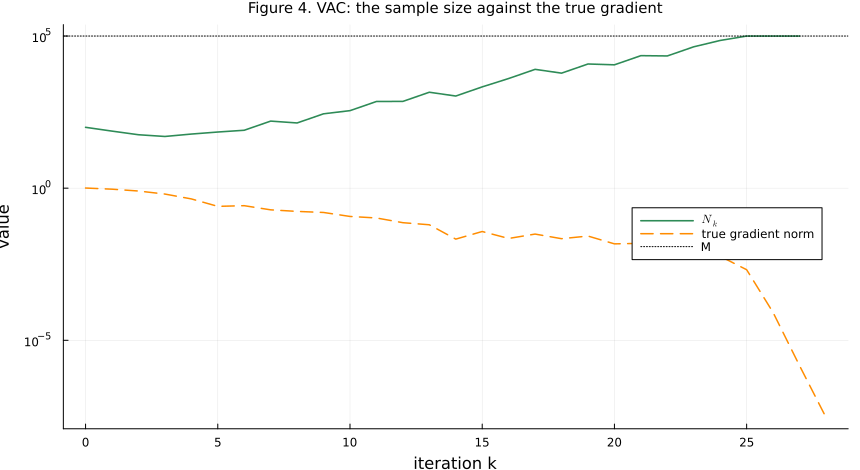

In [17]:
let plt = plot(xlabel = "iteration k", legend = :right, size = (860, 470),
               title = "Figure 4. VAC: the sample size against the true gradient",
               titlefontsize = 10, yscale = :log10, ylabel = "value")
    ss = RUNS["Naive, VAC (prefix)"].st.solver_specific
    N  = ss[:grad_sample_trajectory]
    tg = get(ss, :true_grad_trajectory, Float64[])
    plot!(plt, 0:length(N)-1, N; label = L"N_k", lw = 1.6, color = :seagreen)
    if !isempty(tg)
        pos = [i for i in eachindex(tg) if isfinite(tg[i]) && tg[i] > 0]
        isempty(pos) || plot!(plt, pos .- 1, tg[pos];
                              label = "true gradient norm", lw = 1.5,
                              color = :darkorange, linestyle = :dash)
    end
    hline!(plt, [PD_M]; label = "M", ls = :dot, color = :black)
    savefig(plt, joinpath(OUTDIR, "predoc_mnl_fig4_vac_hazard.pdf"))
    display(plt)
end

## 6. Question 4: the two variance estimates, *tv* against *sHs*

The PreDoc labels its runs *tv* when the true (empirical) variance enters the
sample-size formula and *sHs* when the outer-product approximation does. The
approximation comes from a first-order expansion of $F(\cdot,\xi)$ about $x_k$,

$$\hat\sigma_{N_k}^2 \approx s_k^\top \tilde B_k s_k - \bigl(\tilde g_k^\top s_k\bigr)^2,$$

and the point of it is that both terms are already formed: $s_k^\top\tilde B_ks_k$
is needed for $\rho_k$ and $\tilde g_k$ is in memory for the model.

The package now computes both on every paired iteration and records both, so the
comparison is between two estimates of one quantity on one batch, not between two
runs. `paired_op_variance` forms the right-hand side as the sample variance of the
scalars $\nabla F_i^\top s_k$, which is algebraically the same and cannot come out
negative.

In [18]:
# First the two estimates against each other on a single run, iteration by
# iteration. This is the comparison the archived-trace route could not make.
let ss = RUNS["Naive, VAI/VAC (nested)"].st.solver_specific
    emp = ss[:paired_variance_trajectory]
    op  = get(ss, :paired_op_variance_trajectory, Float64[])
    good = [i for i in eachindex(emp)
            if i <= length(op) && isfinite(emp[i]) && isfinite(op[i]) && emp[i] > 0]
    println("="^96)
    println("TABLE 5. The empirical variance against the outer-product approximation,")
    println("both formed on the same batch at the same iterate on the nested run.")
    println("="^96)
    if isempty(good)
        println("Neither estimate was formed on this run.")
    else
        rat = op[good] ./ emp[good]
        @printf("%-34s %d\n", "iterations with both finite:", length(good))
        @printf("%-34s %.6f\n", "median ratio sHs / tv:", median(rat))
        @printf("%-34s [%.6f, %.6f]\n", "ratio range:", minimum(rat), maximum(rat))
        @printf("%-34s %d\n", "iterations with ratio outside [0.5, 2]:",
                count(r -> r < 0.5 || r > 2.0, rat))
        @printf("%-34s %d of %d\n", "negative outer-product values:",
                count(<(0.0), op[good]), length(good))
        println()
        println("The approximation is a Taylor expansion in ‖s_k‖, so it is good where")
        println("the step is small and degrades where it is large. The ratio's spread")
        println("is that effect, not an estimation error.")
    end
end

TABLE 5. The empirical variance against the outer-product approximation,
both formed on the same batch at the same iterate on the nested run.
iterations with both finite:       26
median ratio sHs / tv:             1.003150
ratio range:                       [0.999912, 1.218152]
iterations with ratio outside [0.5, 2]: 0
negative outer-product values:     0 of 26

The approximation is a Taylor expansion in ‖s_k‖, so it is good where
the step is small and degrades where it is large. The ratio's spread
is that effect, not an estimation error.


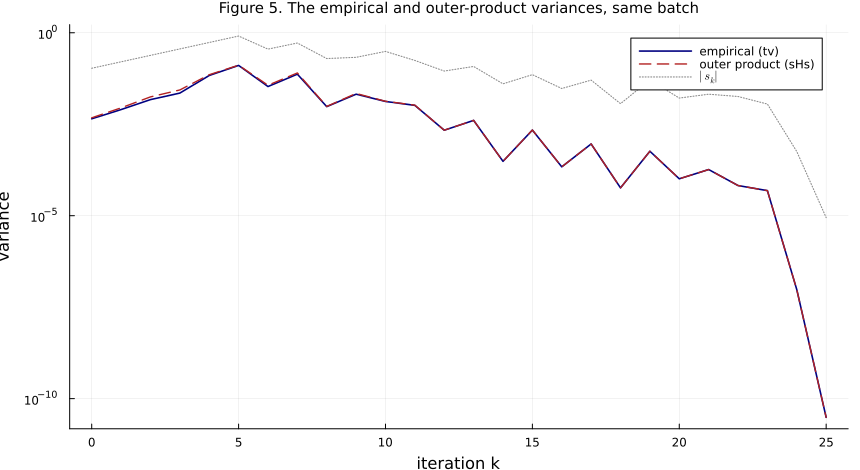

In [19]:
let ss = RUNS["Naive, VAI/VAC (nested)"].st.solver_specific
    emp = ss[:paired_variance_trajectory]
    op  = get(ss, :paired_op_variance_trajectory, Float64[])
    stp = ss[:step_trajectory]
    good = [i for i in eachindex(emp)
            if i <= length(op) && isfinite(emp[i]) && isfinite(op[i]) &&
               emp[i] > 0 && op[i] > 0]
    plt = plot(xlabel = "iteration k", ylabel = "variance", yscale = :log10,
               legend = :topright, size = (860, 470),
               title = "Figure 5. The empirical and outer-product variances, same batch",
               titlefontsize = 10)
    if !isempty(good)
        plot!(plt, good .- 1, emp[good]; label = "empirical (tv)", lw = 1.6, color = :navy)
        plot!(plt, good .- 1, op[good]; label = "outer product (sHs)", lw = 1.4,
              color = :firebrick, linestyle = :dash)
        gs = [i for i in good if i <= length(stp) && isfinite(stp[i]) && stp[i] > 0]
        isempty(gs) || plot!(plt, gs .- 1, stp[gs]; label = L"\|s_k\|", lw = 1.1,
                             color = :grey55, linestyle = :dot)
    end
    savefig(plt, joinpath(OUTDIR, "predoc_mnl_fig5_variances.pdf"))
    display(plt)
end

In [20]:
# Then the two as *rules*: does the choice change the run?
pd_go!("Naive tv, VAI/VAC", pd_naive(variance = :empirical); scheme = :nested)
pd_go!("Naive sHs, VAI/VAC", pd_naive(variance = :outer_product); scheme = :nested)

pd_table([ROWS[findfirst(r -> r.label == l, ROWS)] for l in
          ("Naive tv, VAI/VAC", "Naive sHs, VAI/VAC")];
         title = "TABLE 6. The same rule sized from each variance estimate in turn.")
println()
println("`needs_scores` becomes true under :outer_product, so the rule is rejected")
println("outright on a problem that supplies no per-observation scores rather than")
println("silently falling back.")

TABLE 6. The same rule sized from each variance estimate in turn.
arm                              iters        status    N_min    N_max       terms    f (true) ‖∇f‖ (true)      acc
------------------------------------------------------------------------------------------------------------------------------
Naive tv, VAI/VAC                   26   first_order       50   100000   9.627e+05    0.781998   7.107e-08   0.6915
Naive sHs, VAI/VAC                  24   first_order       50   100000   8.304e+05    0.781998   4.736e-07   0.6915

f and ‖∇f‖ are over all 100000 individuals at the point the run stopped,
computed here and not by the solver. `status` is what the run reported:
`first_order` means its own test was met, `max_iter` means it ran out.

`needs_scores` becomes true under :outer_product, so the rule is rejected
outright on a problem that supplies no per-observation scores rather than
silently falling back.


## 7. BHHH against the subsampled true Hessian

The PreDoc's *BHHH* and *TH* labels are the outer-product approximation and a
subsampled true Hessian. Both are available here on the same problem, which is the
comparison Table 1 was the premise for: BHHH is justified by the information
identity, and Table 1 measured how nearly the identity holds.

`BHHHModel` is positive semidefinite by construction, so it can never report
negative curvature. On this problem that costs nothing, because the multinomial
logit objective is convex: each per-observation Hessian is a covariance under the
choice probabilities. The two models are therefore being compared on approximation
quality alone, with no question of curvature exploitation on either side.

In [21]:
pd_go!("Naive, VAI/VAC, exact H", pd_naive(); scheme = :nested, model = ExactHessian())

pd_table([ROWS[findfirst(r -> r.label == l, ROWS)] for l in
          ("Naive, VAI/VAC (nested)", "Naive, VAI/VAC, exact H")];
         title = "TABLE 7. BHHH against the exact Hessian, nested scheme, everything else fixed.")

TABLE 7. BHHH against the exact Hessian, nested scheme, everything else fixed.
arm                              iters        status    N_min    N_max       terms    f (true) ‖∇f‖ (true)      acc
------------------------------------------------------------------------------------------------------------------------------
Naive, VAI/VAC (nested)             26   first_order       50   100000   9.627e+05    0.781998   7.107e-08   0.6915
Naive, VAI/VAC, exact H             31   first_order       50   100000   1.064e+06    0.781998   1.210e-09   0.6915

f and ‖∇f‖ are over all 100000 individuals at the point the run stopped,
computed here and not by the solver. `status` is what the run reported:
`first_order` means its own test was met, `max_iter` means it ran out.


In [22]:
let a = RUNS["Naive, VAI/VAC (nested)"], b = RUNS["Naive, VAI/VAC, exact H"]
    println()
    # One line per model carrying every number of the comparison, so that the
    # row can be checked against a single line of output rather than assembled
    # from two.
    println("model            iters        terms   ‖∇f‖ (true)   CG iters")
    println("-"^62)
    for (nm, r) in (("BHHH", a), ("exact", b))
        @printf("%-12s %8d %12.3e %13.3e %10d\n", nm, r.st.iter,
                float(samples_used(r.nlp).total),
                norm(true_gradient(PROB, r.st.solution)),
                sum(r.st.solver_specific[:cg_iters_trajectory]))
    end
    println()
    @printf("CG iterations (total)   : BHHH %d, exact %d\n",
            sum(a.st.solver_specific[:cg_iters_trajectory]),
            sum(b.st.solver_specific[:cg_iters_trajectory]))
    @printf("neval_hprod reports     : BHHH %d, exact %d\n",
            neval_hprod(a.nlp), neval_hprod(b.nlp))
    println("The BHHH figure is 0 because `OuterProductOperator` forms B·v from the")
    println("score matrix without going through the NLP's `hprod!`, so the counter")
    println("never sees it. It did do one product per CG iteration. Read the CG line,")
    println("not the counter, when the model is an outer product.")
    println()
    println("The exact Hessian on this problem costs O(N·J·p²) per batch against")
    println("O(N·J·p) for the score matrix BHHH is built from, and the score matrix")
    println("is computed for the gradient anyway. That is the PreDoc's argument for")
    println("the outer product, and at p = $(PD_P) the constant is small enough that")
    println("the two run in comparable time; it is the p-dependence that matters.")
end


model            iters        terms   ‖∇f‖ (true)   CG iters
--------------------------------------------------------------
BHHH               26    9.627e+05     7.107e-08         55
exact              31    1.064e+06     1.210e-09         53

CG iterations (total)   : BHHH 55, exact 53
neval_hprod reports     : BHHH 0, exact 53
The BHHH figure is 0 because `OuterProductOperator` forms B·v from the
score matrix without going through the NLP's `hprod!`, so the counter
never sees it. It did do one product per CG iteration. Read the CG line,
not the counter, when the model is an outer product.

The exact Hessian on this problem costs O(N·J·p²) per batch against
O(N·J·p) for the score matrix BHHH is built from, and the score matrix
is computed for the gradient anyway. That is the PreDoc's argument for
the outer product, and at p = 10 the constant is small enough that
the two run in comparable time; it is the p-dependence that matters.


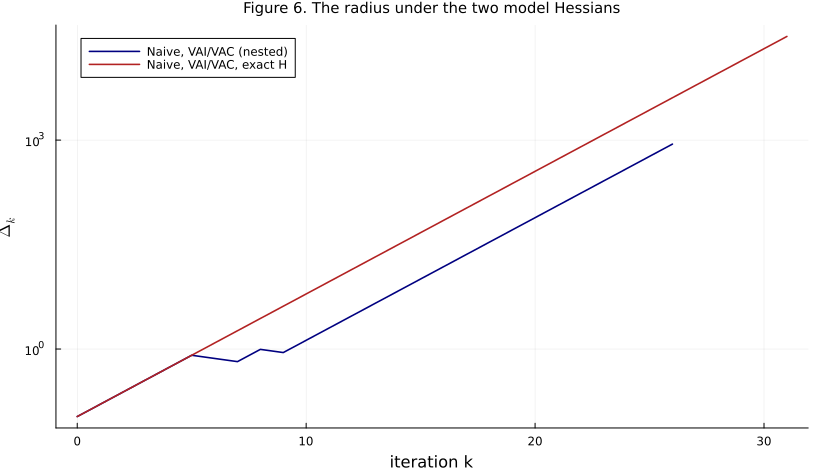

In [23]:
let plt = plot(xlabel = "iteration k", ylabel = L"\Delta_k", yscale = :log10,
               legend = :topleft, size = (820, 470),
               title = "Figure 6. The radius under the two model Hessians",
               titlefontsize = 10)
    for (lab, col) in (("Naive, VAI/VAC (nested)", :navy),
                       ("Naive, VAI/VAC, exact H", :firebrick))
        d = RUNS[lab].st.solver_specific[:delta_trajectory]
        pos = [i for i in eachindex(d) if isfinite(d[i]) && d[i] > 0]
        plot!(plt, pos .- 1, d[pos]; label = lab, lw = 1.6, color = col)
    end
    savefig(plt, joinpath(OUTDIR, "predoc_mnl_fig6_radius.pdf"))
    display(plt)
end

## 8. Everything in one table

Every arm run above, scored the same way after the fact.

In [24]:
pd_table(ROWS; title = "TABLE 8. Every arm, scored identically.")

TABLE 8. Every arm, scored identically.
arm                              iters        status    N_min    N_max       terms    f (true) ‖∇f‖ (true)      acc
------------------------------------------------------------------------------------------------------------------------------
raw, VAI                           300      max_iter       10     3946   1.982e+04    1.510823   3.284e-01   0.6509
Naive(0.75,2), VAI                 300      max_iter       50     4717   9.794e+05    0.782861   2.683e-02   0.6924
monotone (a=1), VAI                120   first_order      100   100000   1.725e+06    0.781998   9.002e-08   0.6915
Naive, VAI/VAC (nested)             26   first_order       50   100000   9.627e+05    0.781998   7.107e-08   0.6915
Naive, VAC (prefix)                 28   first_order       50   100000   1.019e+06    0.781998   2.926e-08   0.6915
Naive tv, VAI/VAC                   26   first_order       50   100000   9.627e+05    0.781998   7.107e-08   0.6915
Naive sHs, VAI/VAC   

## 9. What was reproduced and what was not

**Reproduced.** The problem is the PreDoc's: five alternatives, $p = 10$,
$N = 100\,000$, generated from the logit model, with $f(0) = \ln 5$ exact and the
information identity measured rather than assumed. The rule is Step 5 with
$z_{0.95}$ agreeing to the four digits quoted. $\Psi_k$ is Naive$(0.75, 2.0)$ with
the floor $N^{\min}_k = 10 + 10k$. The trust-region constants and $\Delta_0$ are the
PreDoc's. All three sample management schemes are implemented to the definitions in
the "Our approach" section, and both variance estimates are available and recorded
together.

**Not reproduced, and why.**

1. *CMS and CMS-cum smoothing.* The PreDoc compares Naive against CMS-cum, and only
   Naive is implemented here. CMS holds the size constant for
   $m = \lceil \epsilon^\beta_k/\tilde\mu_k\rceil$ iterations, which needs the rule
   to carry a countdown across iterations rather than to answer from the current
   state. It is a different shape of rule, not a different constant.

2. *A separate Hessian sample $\mathcal{H}_k$.* The PreDoc's Step 1 draws
   $\mathcal{H}_k$, possibly non-uniformly, and then assumes
   $\mathcal{H}_k \subset \mathcal{S}_k$ throughout. Here the model is built on the
   gradient batch, which is the case $\mathcal{H}_k = \mathcal{S}_k$.

3. *The generating noise.* The PreDoc says a mean-zero perturbation was added to
   $\beta^*$ during generation and that the information identity nonetheless holds.
   Taken literally that is a mixed-logit generating process fitted with a plain
   logit, which is misspecification, and `MultinomialLogit(noise = σ)` implements
   it and shows the identity error rising with $\sigma$. The runs above use
   `noise = 0`, the correctly specified case, so that the identity premise Table 1
   checks is the one the runs rely on. The two readings are not reconciled here.

4. *A convergence criterion.* The PreDoc states none, and iteration counts are read
   off its figures. The cap of $PD_KMAX$ iterations and the gradient tolerance here
   are ours, which is why an arm reporting `max_iter` is reported as not having
   converged rather than as having taken that many iterations.

**What the runs say**, question by question.

*1. Is the raw certified size unstable?* Yes, and more sharply than "unstable"
conveys. It sits at $N_{\min} = 10$ for 79% of the run, and the transition ratio
$N_{k+1}/N_k$ ranges over $[0.0025, 263]$. With ten individuals and ten parameters
the batch problem is degenerate, so the run is not solving the problem at all: it
ends at $f = 1.51$ against $\ln 5 = 1.609$ at the starting point, having moved
almost nowhere.

*2. Does the naive smoothing fix it?* It improves the run by a long way and does
not fix it. Naive$(0.75,2)$ with the floor brings the true objective to $0.7829$
and the true gradient to $2.7\times10^{-2}$, against $1.51$ and $0.33$ raw, but the
arm still reports `max_iter` at 300 iterations. What converges under independent
draws is the extreme setting $a = 1$, in 120 iterations and at 1.7 times the term
cost of any other arm. So the lower bound is doing real work, and on this problem
$a = 0.75$ is not tight enough on its own.

*3. Do the common-variable schemes converge in fewer iterations?* Yes, and the
gap is not marginal: 26 iterations nested and 28 prefix, against an independent
arm that does not converge in 300. But the iteration count is not the cost. All
three arms spend within 6% of the same number of term evaluations, because the
converging runs reach the full population and their late iterations are
correspondingly expensive. The defensible statement is that for the same budget
one arm converged and the other did not, which is stronger than a ratio of
iteration counts and different in kind.

The mechanism the PreDoc offers, that common variables stop $\tilde f$ moving for
reasons unrelated to the step, is not confirmed here. The natural diagnostic
ranks the schemes in the wrong order, and the comparison is confounded because at
a matched iteration index the three runs are at different stages of convergence.
We report it and decline to conclude from it.

*The VAC hazard.* The PreDoc warns that the prefix scheme can overfit its own
prefix: the sample size spikes, falls, and may cycle. The signature is present.
Counting falls in $N_k$ that come with the **true** gradient rising, the prefix
run shows 4 of 8 against 1 of 6 for the nested run, with a worst rise of
$1.78\times$ against $1.15\times$. That is the ordering the PreDoc predicts, VAC
worse than VAI/VAC, on runs that are identical in every other respect. It did not
prevent convergence here, and on i.i.d. data the first hundred individuals are an
ordinary sample; sorted or clustered data is where the hazard would bite.

*4. Does the outer-product variance stand in for the empirical one?* On this
problem, closely. Over the 26 paired iterations of the nested run the ratio
$\hat\sigma^2_{sHs}/\hat\sigma^2_{tv}$ has median $1.0032$ and range
$[0.9999, 1.2182]$, with no negative values, and the run sized from it converges in
24 iterations rather than 26 and at a lower term cost. The agreement is unsurprising
in direction and worth quantifying in size: the approximation is first order in
$\|s_k\|$, and this run's steps are small once the radius settles.

Two cautions on that. The outer product is used here as an estimate of
$\mathrm{Var}[\nabla F]$, which is a **different** requirement from the information
identity: it does not ask $\tilde B$ to approximate the Hessian, so it stays
legitimate on a misspecified model where BHHH as a Hessian is not. And the close
agreement is a property of this problem, where Table 1 shows the identity holding
to 1.2%; it should not be carried to a model where it does not.

In [25]:
println("="^96)
println("Figures written to ", OUTDIR)
for f in ("predoc_mnl_fig1_raw_size.pdf", "predoc_mnl_fig2_smoothing.pdf",
          "predoc_mnl_fig3_schemes.pdf", "predoc_mnl_fig4_vac_hazard.pdf",
          "predoc_mnl_fig5_variances.pdf", "predoc_mnl_fig6_radius.pdf")
    p = joinpath(OUTDIR, f)
    @printf("  %-40s %s\n", f, isfile(p) ? "ok" : "MISSING")
end
println()
@printf("%d arms run, %d figures, %.1f s of solver time in total\n",
        length(ROWS), 6, sum(r -> r.secs, ROWS))

Figures written to c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\notebooks\Sampling
  predoc_mnl_fig1_raw_size.pdf             ok
  predoc_mnl_fig2_smoothing.pdf            ok
  predoc_mnl_fig3_schemes.pdf              ok
  predoc_mnl_fig4_vac_hazard.pdf           ok
  predoc_mnl_fig5_variances.pdf            ok
  predoc_mnl_fig6_radius.pdf               ok

8 arms run, 6 figures, 62.3 s of solver time in total
